# 前期准备

## 导包

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import time
import seaborn as sns
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = 'SimHei'
import warnings
warnings.filterwarnings('ignore')

## 明确问题

1. 用户画像，包含使用平台贷款业务的用户的性别比例，学历水平，是否为旧有用户，
年龄分布等信息。|
2. 资金储备，每日借款金额大概多少？波动有多大？从而公司每日需准备多少资金可以
保证不会出现资金短缺？
3. 用户逾期率，借款人的初始评级、借款类型、性别、年龄等特征对于逾期还款的概率
有无显著影响？哪些群体逾期还款率明显较高？
4. 借款利率，哪些群体更愿意接受较高的借款利率？

## 数据清洗

In [20]:
data = pd.read_csv('LC.csv')
data


,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,户口认证,视频认证,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,未成功认证,成功认证,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,成功认证,未成功认证,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,成功认证,成功认证,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,成功认证,成功认证,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328548,32819271,2389,6,20.0,2017-01-30,C,其他,否,26,男,...,未成功认证,未成功认证,未成功认证,未成功认证,未成功认证,1,10000.0,7610.82,3,0
328549,32819381,7000,12,20.0,2017-01-30,C,其他,否,22,男,...,未成功认证,未成功认证,未成功认证,未成功认证,未成功认证,1,2100.0,0.00,12,0
328550,32819451,2017,6,20.0,2017-01-30,C,其他,否,36,女,...,未成功认证,成功认证,未成功认证,未成功认证,未成功认证,5,19656.0,10982.53,20,2
328551,32819511,6406,12,20.0,2017-01-30,C,其他,否,33,男,...,未成功认证,未成功认证,未成功认证,未成功认证,未成功认证,1,3500.0,1593.59,7,0


### 检查每一个字段的格式

In [23]:
# 没有空值，借款成功日期的格式有问题，要转化成日期格式的
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328553 entries, 0 to 328552
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ListingId  328553 non-null  int64  
 1   借款金额       328553 non-null  int64  
 2   借款期限       328553 non-null  int64  
 3   借款利率       328553 non-null  float64
 4   借款成功日期     328553 non-null  object 
 5   初始评级       328553 non-null  object 
 6   借款类型       328553 non-null  object 
 7   是否首标       328553 non-null  object 
 8   年龄         328553 non-null  int64  
 9   性别         328553 non-null  object 
 10  手机认证       328553 non-null  object 
 11  户口认证       328553 non-null  object 
 12  视频认证       328553 non-null  object 
 13  学历认证       328553 non-null  object 
 14  征信认证       328553 non-null  object 
 15  淘宝认证       328553 non-null  object 
 16  历史成功借款次数   328553 non-null  int64  
 17  历史成功借款金额   328553 non-null  float64
 18  总待还本金      328553 non-null  float64
 19  历史正常还款期数   328553 non-n

In [ ]:

data['借款成功日期'] = pd.to_datetime(data['借款成功日期'], format='mixed')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328553 entries, 0 to 328552
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ListingId  328553 non-null  int64         
 1   借款金额       328553 non-null  int64         
 2   借款期限       328553 non-null  int64         
 3   借款利率       328553 non-null  float64       
 4   借款成功日期     328553 non-null  datetime64[ns]
 5   初始评级       328553 non-null  object        
 6   借款类型       328553 non-null  object        
 7   是否首标       328553 non-null  object        
 8   年龄         328553 non-null  int64         
 9   性别         328553 non-null  object        
 10  手机认证       328553 non-null  object        
 11  户口认证       328553 non-null  object        
 12  视频认证       328553 non-null  object        
 13  学历认证       328553 non-null  object        
 14  征信认证       328553 non-null  object        
 15  淘宝认证       328553 non-null  object        
 16  历史成功借款次数   328553 no

### 简单的了解一下数据

In [31]:
# 根据“借款金额”来看那个最大值好像有一点不正常
# 根据“利率”来说，我查了一下，24-36叫高利贷，好家伙，这个刚好擦边到24.现在的正常银行贷款利率是3个点左右。这也算是暴利了。
# 根据“年龄”来说，50%以上的都是年轻人，现在都这么疯狂的吗？
# 根据“逾期”字段来说，逾期的还是比较少的。
# 根据“借款金额”字段来说，大部分人借款是在10000以内的，说明小额贷款比较多
# 

data.describe([.25,.50,.75,.99]).T

,count,mean,min,25%,50%,75%,99%,max,std
ListingId,328553.0,19079479.261072,126541.0,11908871.0,19523251.0,26298621.0,32595910.2,32819531.0,8375769.043234
借款金额,328553.0,4423.816906,100.0,2033.0,3397.0,5230.0,17064.0,500000.0,11219.664024
借款期限,328553.0,10.213594,1.0,6.0,12.0,12.0,12.0,24.0,2.780444
借款利率,328553.0,20.601439,6.5,20.0,20.0,22.0,24.0,24.0,1.772408
借款成功日期,328553,2016-08-05 22:21:24.987201280,2015-01-01 00:00:00,2016-05-08 00:00:00,2016-09-11 00:00:00,2016-12-01 00:00:00,2017-01-26 00:00:00,2017-01-30 00:00:00,NaN
年龄,328553.0,29.143042,17.0,24.0,28.0,33.0,49.0,56.0,6.624286
历史成功借款次数,328553.0,2.323159,0.0,0.0,2.0,3.0,12.0,649.0,2.922361
历史成功借款金额,328553.0,8785.856771,0.0,0.0,5000.0,10355.0,58105.4,7405926.0,35027.363482
总待还本金,328553.0,3721.665361,0.0,0.0,2542.41,5446.81,19646.7092,1172652.87,8626.061205
历史正常还款期数,328553.0,9.947658,0.0,0.0,5.0,13.0,66.0,2507.0,14.839899


# 分析

## 3.11.用户画像，包含使用平台贷款业务的用户的性别比例，学历水平，是否为旧有用户，年龄分布等信息。

### 性别比例

In [32]:
data.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,户口认证,视频认证,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,未成功认证,成功认证,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,成功认证,未成功认证,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,成功认证,成功认证,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,成功认证,成功认证,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14


In [ ]:
# 男生占比
(data['性别'].value_counts()['男']/(data['性别'].value_counts()['男']+data['性别'].value_counts()['女']))

np.float64(0.675525714268322)

In [ ]:
# 男生贷款比较多，是因为顾家的缘故吗？


# 直接得到比例并乘以 100 转成百分比
gender_ratio = data['性别'].value_counts(normalize=True) * 100

# 格式化输出，保留两位小数
print(gender_ratio.apply(lambda x: f"{x:.2f}%"))

性别
男    67.55%
女    32.45%
Name: proportion, dtype: object


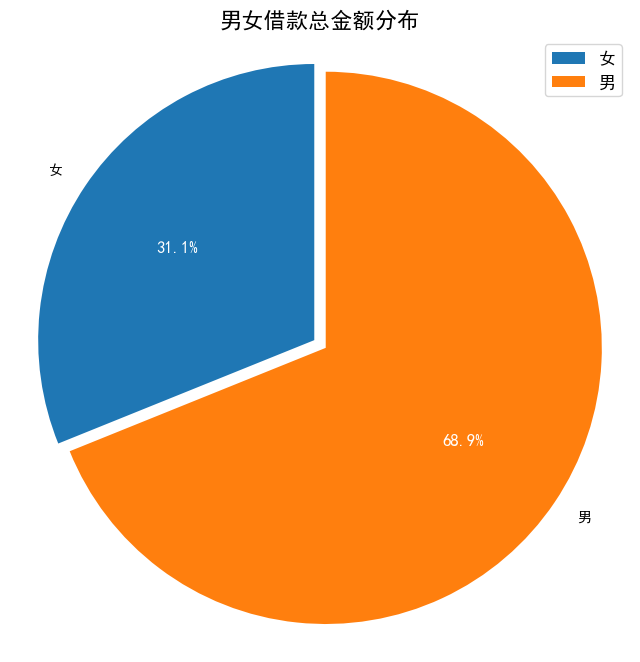

=== 男女借款总金额 ===
性别
女     452128926
男    1001329390
Name: 借款金额, dtype: int64

=== 男女借款平均金额 ===
性别
女    4241.08
男    4511.59
Name: 借款金额, dtype: float64


In [54]:
data_clean = data.dropna(subset=['性别', '借款金额'])

# 4. 统计男女借款金额（二选一，或都运行对比）
# 方式1：统计男女借款总金额（看整体贡献）
gender_amount_total = data_clean.groupby('性别')['借款金额'].sum()
# 方式2：统计男女借款平均金额（看人均借款水平）
gender_amount_mean = data_clean.groupby('性别')['借款金额'].mean().round(2)  # 保留2位小数

# 5. 绘制饼图（以“总金额”为例，想画平均金额就把gender_amount_total换成gender_amount_mean）
plt.figure(figsize=(8, 8))  # 设置饼图大小（正方形更美观）
colors = ['#1f77b4', '#ff7f0e']  # 自定义颜色（蓝色=男，橙色=女，可修改）

# 绘制饼图，核心参数说明：
# autopct：显示百分比（%.1f%% 表示保留1位小数的百分比）
# labels：饼图扇区标签
# colors：扇区颜色
# startangle：饼图起始角度（90度是正上方，更美观）
# explode：扇区分隔（[0.05, 0] 让男性扇区稍微突出，可选）
patches, texts, autotexts = plt.pie(
    gender_amount_total,
    labels=gender_amount_total.index,
    colors=colors,
    autopct='%.1f%%',
    startangle=90,
    explode=[0.05, 0]  # 可选：让其中一个扇区突出，增强视觉效果
)

# 优化饼图文字样式（让百分比更清晰）
for autotext in autotexts:
    autotext.set_color('white')  # 百分比文字设为白色
    autotext.set_fontsize(12)    # 文字大小

# 6. 添加标题和图例
plt.title('男女借款总金额分布', fontsize=16)  # 标题（画平均金额就改标题为“男女借款平均金额分布”）
plt.legend(loc='upper right', fontsize=12)  # 图例位置（右上）

# 保证饼图是正圆形
plt.axis('equal')

# 显示饼图
plt.show()

# 7. 打印统计结果（方便核对数值）
print("=== 男女借款总金额 ===")
print(gender_amount_total)
print("\n=== 男女借款平均金额 ===")
print(gender_amount_mean)

结论：男生的比例将近是女生的俩倍，但是男生和女生的平均贷款差不多，所以他们的贷款能力是差不多的，但是男生的多一点而已。

### 学历认证情况比例

In [ ]:

# 直接得到比例并乘以 100 转成百分比
gender_ratio = data['学历认证'].value_counts(normalize=True) * 100

# 格式化输出，保留两位小数
print(gender_ratio.apply(lambda x: f"{x:.2f}%"))


学历认证
未成功认证    65.26%
成功认证     34.74%
Name: proportion, dtype: object


### 是否为旧有用户

In [48]:
# 看来大部分是老用户啊，73的老用户


# 直接得到比例并乘以 100 转成百分比
gender_ratio = data['是否首标'].value_counts(normalize=True) * 100

# 格式化输出，保留两位小数
print(gender_ratio.apply(lambda x: f"{x:.2f}%"))


是否首标
否    73.38%
是    26.62%
Name: proportion, dtype: object


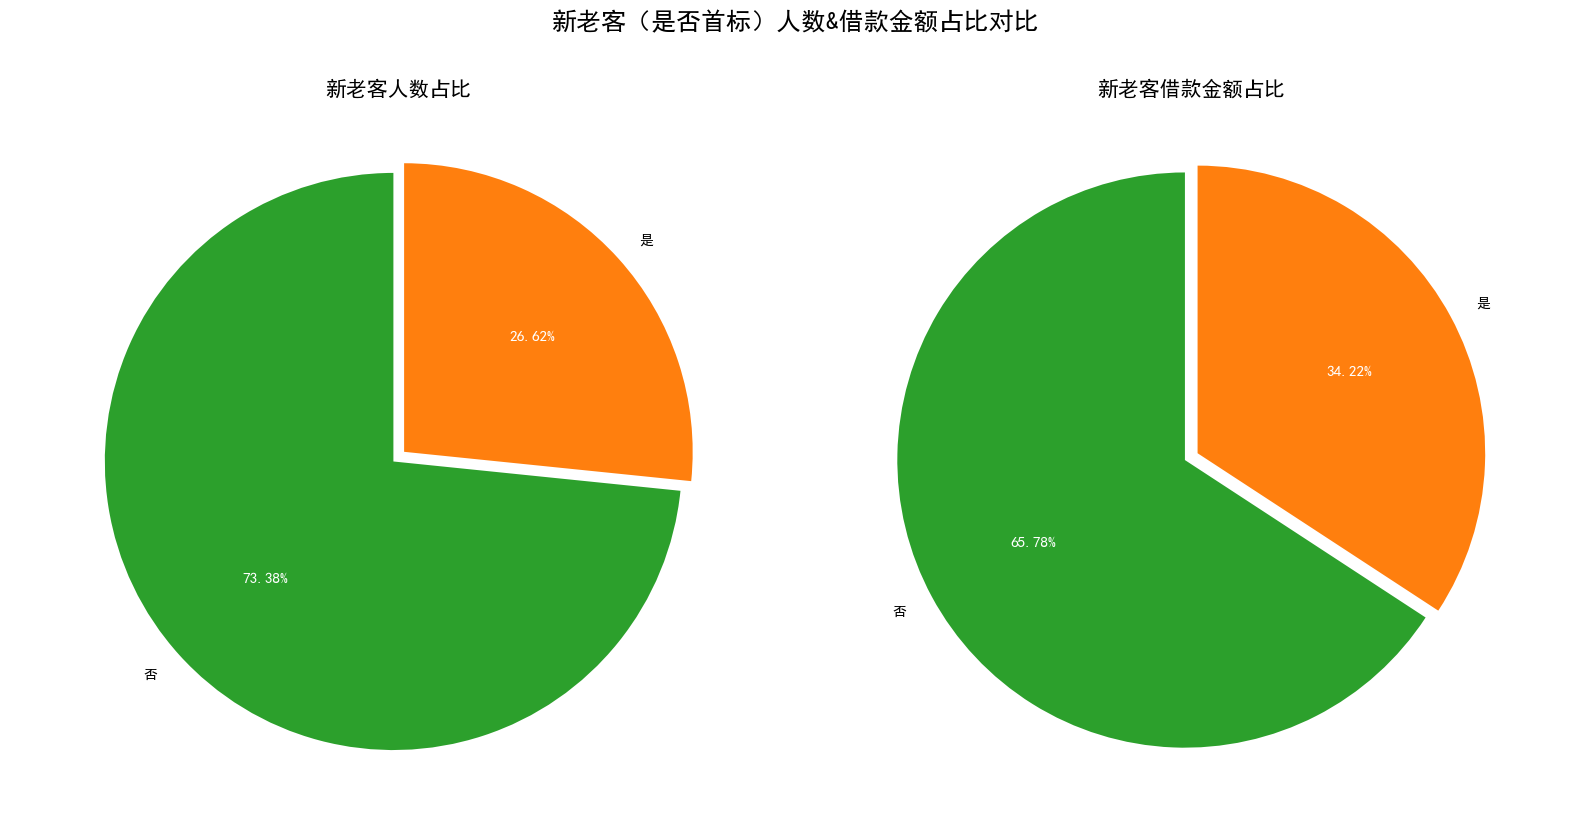

=== 新老客人数统计 ===
是否首标
否    241090
是     87463
Name: count, dtype: int64

=== 新老客人数占比（%）===
是否首标
否    73.38
是    26.62
Name: proportion, dtype: float64

=== 新老客借款总金额 ===
是否首标
否    956102749
是    497355567
Name: 借款金额, dtype: int64

=== 新老客借款金额占比（%）===
是否首标
否    65.78
是    34.22
Name: 借款金额, dtype: float64


In [55]:
# 4. 统计两个核心维度
## 4.1 新老客人数占比（百分比）
user_count_ratio = data_clean['是否首标'].value_counts(normalize=True) * 100
## 4.2 新老客借款金额占比（百分比）
amount_total_ratio = data_clean.groupby('是否首标')['借款金额'].sum()
amount_total_ratio = (amount_total_ratio / amount_total_ratio.sum()) * 100

# 5. 绘制双饼图（1行2列，对比展示）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))  # 1行2列，总画布大小16*8
colors = ['#2ca02c', '#ff7f0e']  # 统一颜色：绿色=否（老客），橙色=是（新客）

# ========== 左图：新老客人数占比饼图 ==========
patches1, texts1, autotexts1 = ax1.pie(
    user_count_ratio,
    labels=user_count_ratio.index,
    colors=colors,
    autopct='%.2f%%',
    startangle=90,
    explode=[0.05, 0]
)
# 优化文字样式
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontsize(11)
ax1.set_title('新老客人数占比', fontsize=15)
ax1.axis('equal')  # 保证正圆

# ========== 右图：新老客借款金额占比饼图 ==========
patches2, texts2, autotexts2 = ax2.pie(
    amount_total_ratio,
    labels=amount_total_ratio.index,
    colors=colors,
    autopct='%.2f%%',
    startangle=90,
    explode=[0.05, 0]
)
# 优化文字样式
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(11)
ax2.set_title('新老客借款金额占比', fontsize=15)
ax2.axis('equal')  # 保证正圆

# 整体标题
fig.suptitle('新老客（是否首标）人数&借款金额占比对比', fontsize=18, y=1.02)

# 调整子图间距，避免标题重叠
plt.tight_layout()
plt.show()

# 6. 打印详细统计结果（方便核对）
print("=== 新老客人数统计 ===")
print(data_clean['是否首标'].value_counts())
print("\n=== 新老客人数占比（%）===")
print(user_count_ratio.round(2))

print("\n=== 新老客借款总金额 ===")
print(data_clean.groupby('是否首标')['借款金额'].sum())
print("\n=== 新老客借款金额占比（%）===")
print(amount_total_ratio.round(2))

In [57]:
data_clean.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,视频认证,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,成功认证,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,成功认证,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,成功认证,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁


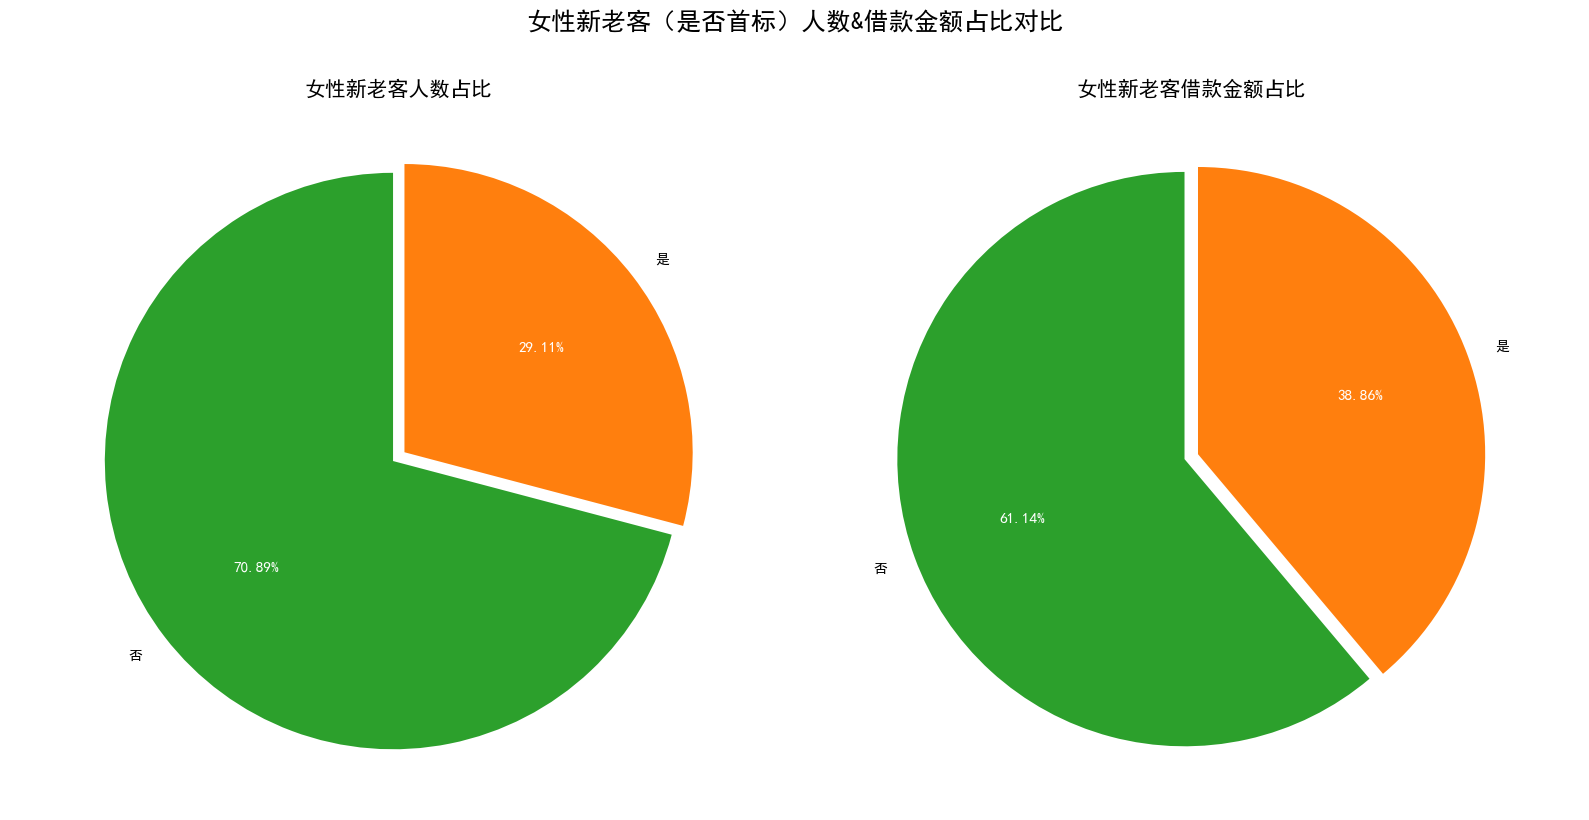

=== 新老客人数统计 ===
是否首标
否    241090
是     87463
Name: count, dtype: int64

=== 新老客人数占比（%）===
是否首标
否    70.89
是    29.11
Name: proportion, dtype: float64

=== 新老客借款总金额 ===
是否首标
否    956102749
是    497355567
Name: 借款金额, dtype: int64

=== 新老客借款金额占比（%）===
是否首标
否    61.14
是    38.86
Name: 借款金额, dtype: float64


In [61]:
# 男生和女生的行数
male = data_clean[data_clean['性别']=="男"]
female = data_clean[data_clean['性别']=="女"]


# 4. 统计两个核心维度
## 4.1 新老客人数占比（百分比）
user_count_ratio = female['是否首标'].value_counts(normalize=True) * 100
## 4.2 新老客借款金额占比（百分比）
amount_total_ratio = female.groupby('是否首标')['借款金额'].sum()
amount_total_ratio = (amount_total_ratio / amount_total_ratio.sum()) * 100

# 5. 绘制双饼图（1行2列，对比展示）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))  # 1行2列，总画布大小16*8
colors = ['#2ca02c', '#ff7f0e']  # 统一颜色：绿色=否（老客），橙色=是（新客）

# ========== 左图：新老客人数占比饼图 ==========
patches1, texts1, autotexts1 = ax1.pie(
    user_count_ratio,
    labels=user_count_ratio.index,
    colors=colors,
    autopct='%.2f%%',
    startangle=90,
    explode=[0.05, 0]
)
# 优化文字样式
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontsize(11)
ax1.set_title('女性新老客人数占比', fontsize=15)
ax1.axis('equal')  # 保证正圆

# ========== 右图：新老客借款金额占比饼图 ==========
patches2, texts2, autotexts2 = ax2.pie(
    amount_total_ratio,
    labels=amount_total_ratio.index,
    colors=colors,
    autopct='%.2f%%',
    startangle=90,
    explode=[0.05, 0]
)
# 优化文字样式
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(11)
ax2.set_title('女性新老客借款金额占比', fontsize=15)
ax2.axis('equal')  # 保证正圆

# 整体标题
fig.suptitle('女性新老客（是否首标）人数&借款金额占比对比', fontsize=18, y=1.02)

# 调整子图间距，避免标题重叠
plt.tight_layout()
plt.show()

# 6. 打印详细统计结果（方便核对）
print("=== 新老客人数统计 ===")
print(data_clean['是否首标'].value_counts())
print("\n=== 新老客人数占比（%）===")
print(user_count_ratio.round(2))

print("\n=== 新老客借款总金额 ===")
print(data_clean.groupby('是否首标')['借款金额'].sum())
print("\n=== 新老客借款金额占比（%）===")
print(amount_total_ratio.round(2))

结论：新客占比虽然少一点，但是新客的消费力更大一些。（不分男女）我都看了的。老客占比比较高，说明平台的粘性高

### 年龄分布

In [50]:
age_stats = data['年龄'].describe()
age_stats

count    328553.000000
mean         29.143042
std           6.624286
min          17.000000
25%          24.000000
50%          28.000000
75%          33.000000
max          56.000000
Name: 年龄, dtype: float64

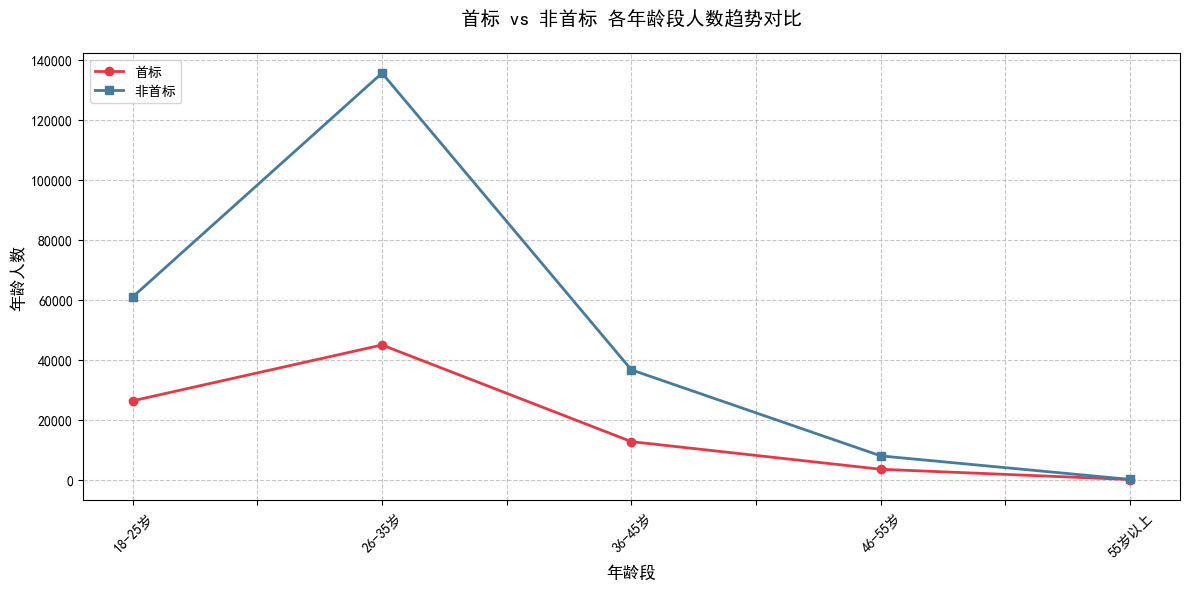

In [77]:
new=data[data['是否首标']=='是']
old=data[data['是否首标']=='否']
# 按日期分组，统计每日借款金额的总和（也可以用均值，根据需求调整）
new_daily = new.groupby('年龄段')['年龄段'].count().rename('首标借款总额')
old_daily = old.groupby('年龄段')['年龄段'].count().rename('非首标借款总额')

# 合并成一个对比用的DataFrame
compare_df = pd.concat([new_daily, old_daily], axis=1).fillna(0)

# ---------------------- 2. 绘制对比折线图 ----------------------
plt.figure(figsize=(12, 6))

# 绘制两条折线
compare_df['首标借款总额'].plot(
    kind='line', 
    marker='o', 
    linewidth=2, 
    color='#E63946', 
    label='首标'
)
compare_df['非首标借款总额'].plot(
    kind='line', 
    marker='s', 
    linewidth=2, 
    color='#457B9D', 
    label='非首标'
)

# ---------------------- 3. 图表美化 ----------------------
plt.title('首标 vs 非首标 各年龄段人数趋势对比', fontsize=14, pad=20)
plt.xlabel('年龄段', fontsize=12)
plt.ylabel('年龄人数', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)  # 日期标签旋转45度，避免重叠
plt.tight_layout()  # 自动调整布局

# ---------------------- 4. 保存与展示 ----------------------
plt.savefig('new_vs_old_trend.png', dpi=300)
plt.show()

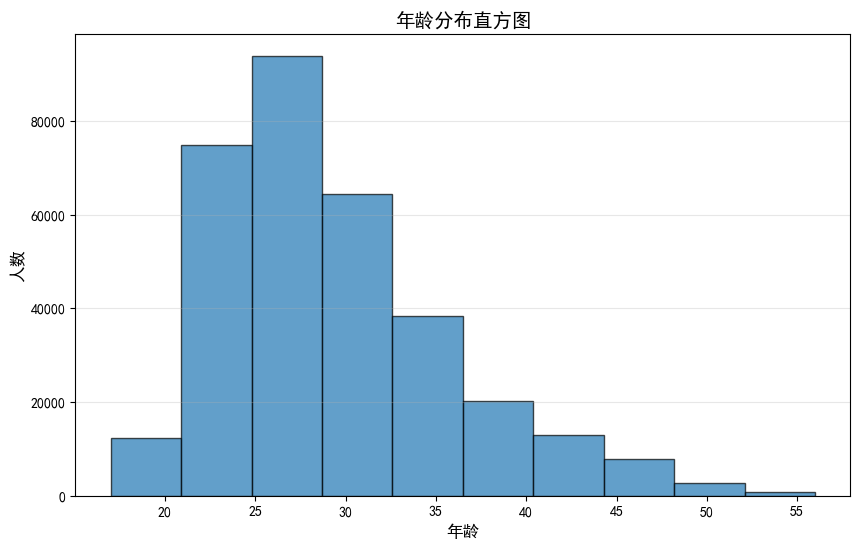

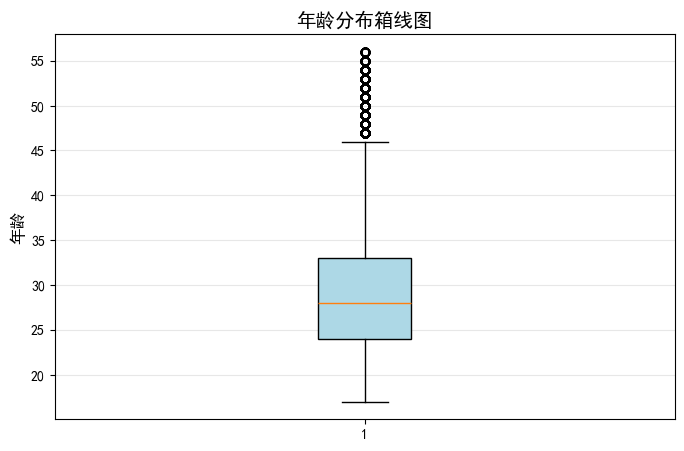


=== 各年龄段人数及占比 ===
            人数  占比(%)
年龄段                  
18-25岁   87219  26.55
26-35岁  180420  54.91
36-45岁   49316  15.01
46-55岁   11431   3.48
55岁以上      165   0.05


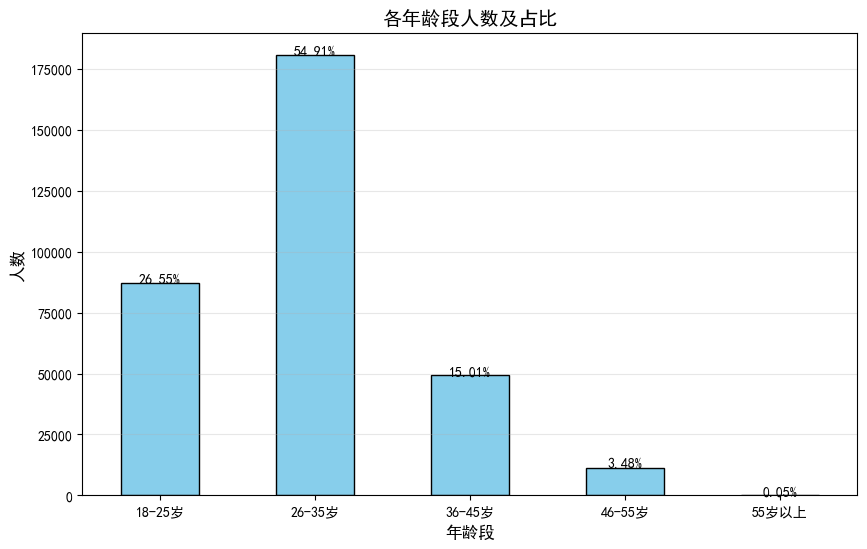

In [53]:
# 4. 第二步：绘制年龄直方图（看哪个年龄段人数最多）
plt.figure(figsize=(10, 6))  # 设置图片大小
# 直方图：bins=分组数（可调整，比如10/20），edgecolor=边框色（避免柱子粘连）
plt.hist(data['年龄'], bins=10, edgecolor='black', alpha=0.7)
plt.title('年龄分布直方图', fontsize=14)  # 标题
plt.xlabel('年龄', fontsize=12)          # x轴标签
plt.ylabel('人数', fontsize=12)          # y轴标签
plt.grid(axis='y', alpha=0.3)            # 显示网格（更易读）
plt.show()

# 5. 第三步：绘制箱线图（检测异常值/离散程度）
plt.figure(figsize=(8, 5))
plt.boxplot(data['年龄'], patch_artist=True, boxprops={'facecolor': 'lightblue'})
plt.title('年龄分布箱线图', fontsize=14)
plt.ylabel('年龄', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. 第四步：按年龄段分组统计（更直观的占比）
# 自定义年龄段区间（可根据你的数据调整，比如18-25,26-35,36-45,45+）
age_bins = [18, 25, 35, 45, 55, 100]
age_labels = ['18-25岁', '26-35岁', '36-45岁', '46-55岁', '55岁以上']

# 分组并统计人数
data['年龄段'] = pd.cut(data['年龄'], bins=age_bins, labels=age_labels, right=False)
age_group_count = data['年龄段'].value_counts().sort_index()  # 按年龄段排序
age_group_ratio = (age_group_count / age_group_count.sum() * 100).round(2)  # 计算占比（保留2位小数）

print("\n=== 各年龄段人数及占比 ===")
result = pd.DataFrame({
    '人数': age_group_count,
    '占比(%)': age_group_ratio
})
print(result)

# 7. 第五步：绘制年龄段占比柱状图
plt.figure(figsize=(10, 6))
age_group_count.plot(kind='bar', color='skyblue', edgecolor='black')
# 在柱子上标注占比
for i, (count, ratio) in enumerate(zip(age_group_count, age_group_ratio)):
    plt.text(i, count + 1, f'{ratio}%', ha='center', fontsize=10)
plt.title('各年龄段人数及占比', fontsize=14)
plt.xlabel('年龄段', fontsize=12)
plt.ylabel('人数', fontsize=12)
plt.xticks(rotation=0)  # x轴标签不旋转（更易读）
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3.22.资金储备，每日借款金额大概多少?波动有多大?从而公司每日需准备多少资金可以保证不会出现资金短缺?

In [80]:
data.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,视频认证,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,成功认证,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,成功认证,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,成功认证,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁


In [ ]:
# 按日期分组，计算每日借款总金额
daily_borrow = data.groupby('借款成功日期')['借款金额'].sum().reset_index()
daily_borrow.columns = ['借款成功日期', '每日借款总额']
daily_borrow

,借款成功日期,每日借款总额
0,2015-01-01,49473
1,2015-01-02,61273
2,2015-01-03,413384
3,2015-01-04,651165
4,2015-01-05,249614
...,...,...
751,2017-01-26,6119649
752,2017-01-27,2772905
753,2017-01-28,2103364
754,2017-01-29,2252701



每日借款金额标准差：1786347.15
变异系数（波动相对值）：92.91%


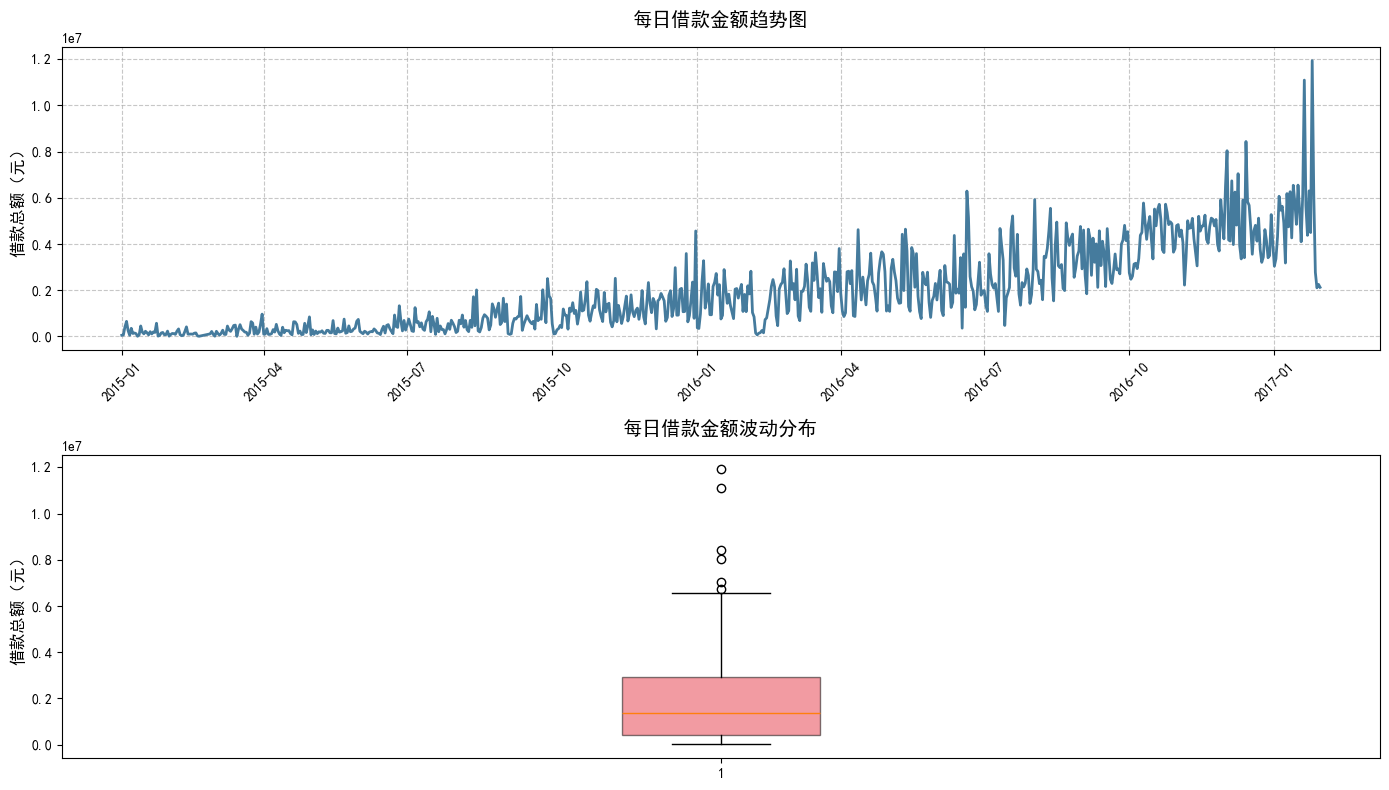


【保守策略】按历史最大日借款额准备：11938937.00 元
【稳健策略】按均值+3倍标准差准备：7281605.36 元
【平衡策略】按95%分位数准备：5194686.75 元


In [89]:
# 计算波动指标（标准差、变异系数）
std_dev = daily_borrow['每日借款总额'].std()
cv = std_dev / daily_borrow['每日借款总额'].mean()
print(f"\n每日借款金额标准差：{std_dev:.2f}")
print(f"变异系数（波动相对值）：{cv:.2%}")

# ---------------------- 3. 可视化展示 ----------------------
plt.figure(figsize=(14, 8))

# 子图1：每日借款金额折线图（看趋势）
plt.subplot(2, 1, 1)
plt.plot(daily_borrow['借款成功日期'], daily_borrow['每日借款总额'], color='#457B9D', linewidth=2)
plt.title('每日借款金额趋势图', fontsize=14, pad=15)
plt.ylabel('借款总额（元）', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# 子图2：每日借款金额箱线图（看波动分布）
plt.subplot(2, 1, 2)
plt.boxplot(daily_borrow['每日借款总额'], patch_artist=True, boxprops=dict(facecolor='#E63946', alpha=0.5))
plt.title('每日借款金额波动分布', fontsize=14, pad=15)
plt.ylabel('借款总额（元）', fontsize=12)

plt.tight_layout()
plt.savefig('daily_borrow_analysis.png', dpi=300)
plt.show()

# ---------------------- 4. 资金储备建议 ----------------------
# 方法1：基于历史最大值（最保守）
max_daily = daily_borrow['每日借款总额'].max()
print(f"\n【保守策略】按历史最大日借款额准备：{max_daily:.2f} 元")

# 方法2：基于均值+3倍标准差（覆盖99.7%的波动）
safe_amount = daily_borrow['每日借款总额'].mean() + 3 * std_dev
print(f"【稳健策略】按均值+3倍标准差准备：{safe_amount:.2f} 元")

# 方法3：基于95%分位数（覆盖大部分极端情况）
quantile_95 = daily_borrow['每日借款总额'].quantile(0.95)
print(f"【平衡策略】按95%分位数准备：{quantile_95:.2f} 元")

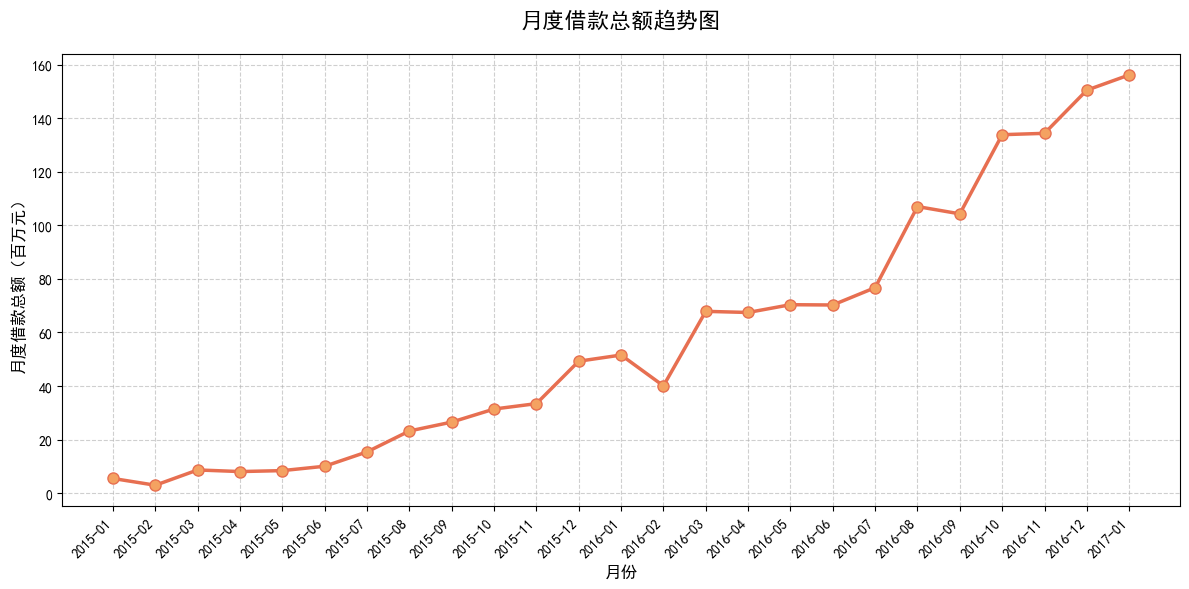

月度借款总额（百万元）：
     月份_str  月度借款总额（百万元）
0   2015-01     5.495048
1   2015-02     2.974525
2   2015-03     8.678800
3   2015-04     8.075770
4   2015-05     8.430741
5   2015-06    10.059413
6   2015-07    15.423063
7   2015-08    23.226904
8   2015-09    26.546298
9   2015-10    31.420038
10  2015-11    33.435692
11  2015-12    49.272395
12  2016-01    51.577586
13  2016-02    40.075798
14  2016-03    67.886261
15  2016-04    67.464658
16  2016-05    70.367865
17  2016-06    70.258765
18  2016-07    76.733743
19  2016-08   107.000566
20  2016-09   104.285349
21  2016-10   133.831696
22  2016-11   134.339383
23  2016-12   150.458045
24  2017-01   156.139914


In [92]:
monthly_borrow = data.groupby(
    pd.Grouper(key='借款成功日期', freq='M')
)['借款金额'].sum().reset_index()
monthly_borrow.columns = ['月份', '月度借款总额']
monthly_borrow['月份_str'] = monthly_borrow['月份'].dt.strftime('%Y-%m')

# ---------------------- 3. 单位转换（核心修改） ----------------------
# 将“元”转换为“百万元”（1百万元 = 1,000,000元）
monthly_borrow['月度借款总额（百万元）'] = monthly_borrow['月度借款总额'] / 1_000_000

# ---------------------- 4. 绘制月度折线图 ----------------------
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_borrow['月份_str'],
    monthly_borrow['月度借款总额（百万元）'],  # 使用转换后的数据
    color='#E76F51',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='#F4A261'
)

# ---------------------- 5. 图表美化（更新标签） ----------------------
plt.title('月度借款总额趋势图', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('月份', fontsize=12)
plt.ylabel('月度借款总额（百万元）', fontsize=12)  # 更新Y轴标签
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存高清图片
plt.savefig('月度借款总额趋势图（百万元）.png', dpi=300)
plt.show()

# 可选：打印转换后的数据
print("月度借款总额（百万元）：")
print(monthly_borrow[['月份_str', '月度借款总额（百万元）']])

## 3.33用户逾期率，借款人的初始评级、借款类型、性别、年龄等特征对于逾期还款的概率有无显著影响?哪些群体逾期还款率明显较高?

In [95]:
data.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,视频认证,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,成功认证,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,成功认证,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,成功认证,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁


In [98]:
data["是否逾期"] = (data["历史逾期还款期数"] > 0).astype(int)
data.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,学历认证,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段,是否逾期
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,未成功认证,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁,1
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁,1
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁,1
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,未成功认证,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁,1
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,未成功认证,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁,1


In [119]:
data['逾期率'] = data['历史逾期还款期数']/(data['历史正常还款期数']+data['历史逾期还款期数'])
data

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段,是否逾期,逾期率
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁,1,0.219178
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁,1,0.071429
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁,1,0.107143
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁,1,0.023810
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁,1,0.106061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328548,32819271,2389,6,20.0,2017-01-30,C,其他,否,26,男,...,未成功认证,未成功认证,1,10000.0,7610.82,3,0,26-35岁,0,0.000000
328549,32819381,7000,12,20.0,2017-01-30,C,其他,否,22,男,...,未成功认证,未成功认证,1,2100.0,0.00,12,0,18-25岁,0,0.000000
328550,32819451,2017,6,20.0,2017-01-30,C,其他,否,36,女,...,未成功认证,未成功认证,5,19656.0,10982.53,20,2,36-45岁,1,0.090909
328551,32819511,6406,12,20.0,2017-01-30,C,其他,否,33,男,...,未成功认证,未成功认证,1,3500.0,1593.59,7,0,26-35岁,0,0.000000


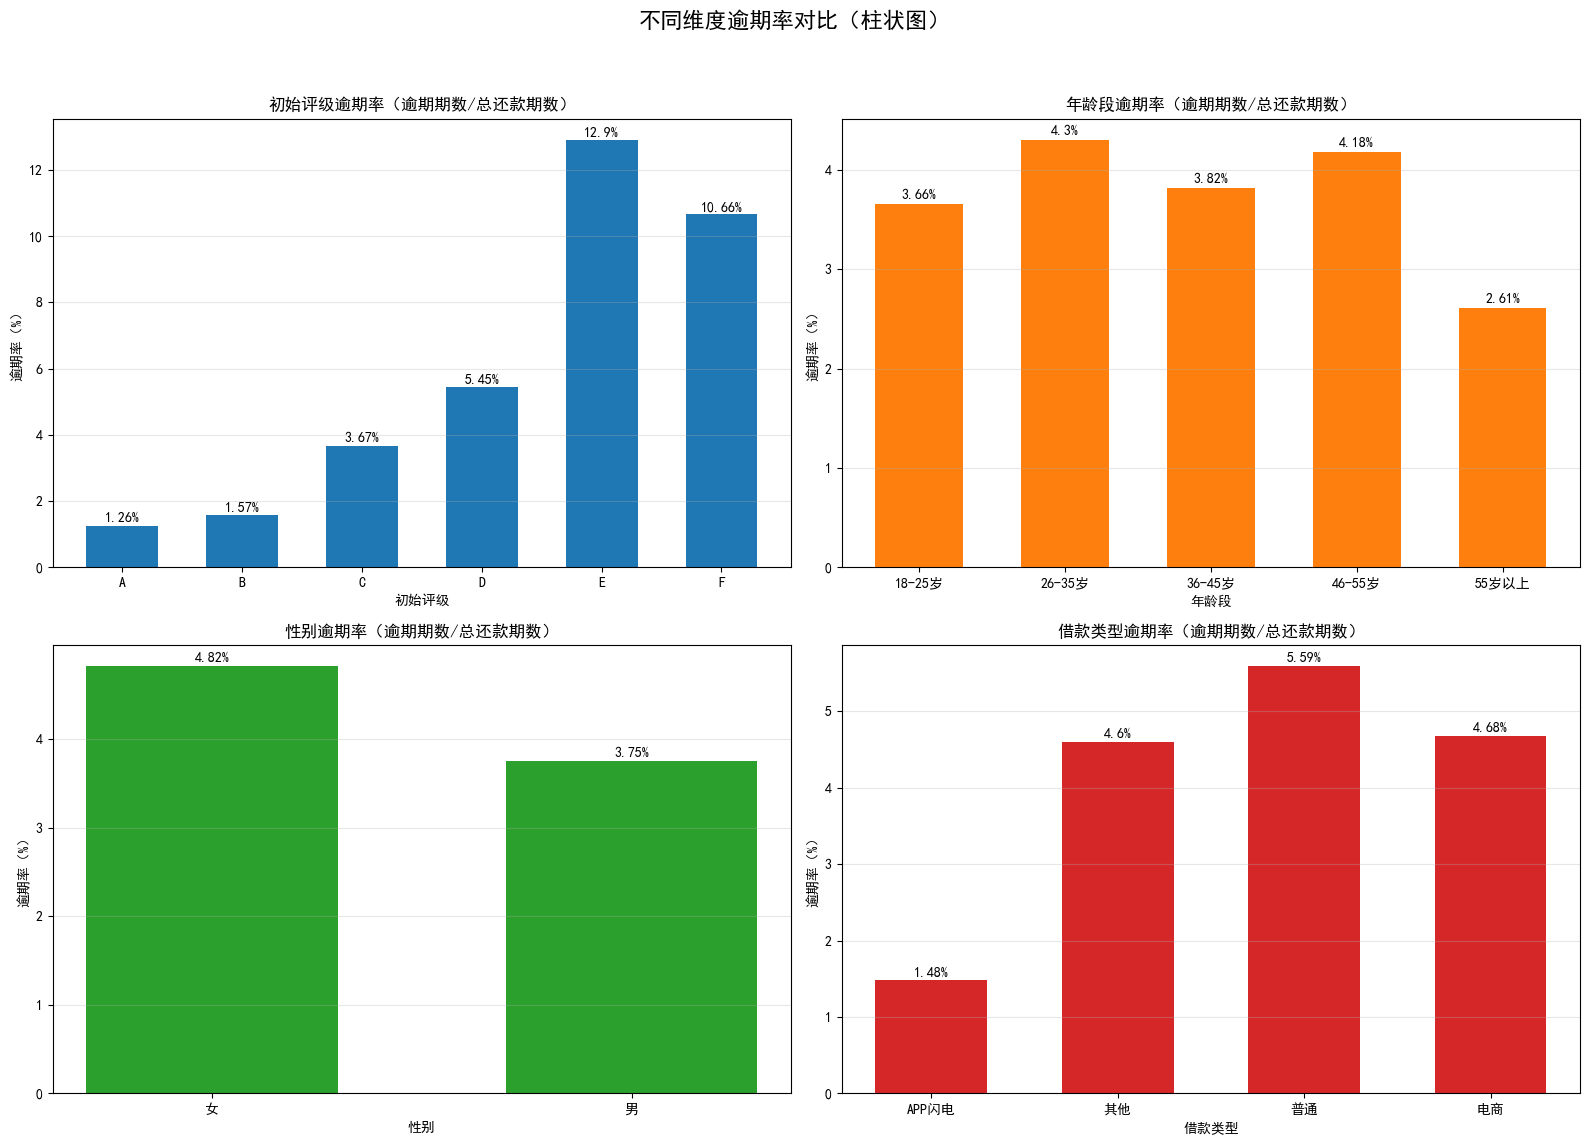

In [120]:
# ---------------------- 第一步：计算四个维度的逾期率（核心逻辑已按你的需求调整） ----------------------
def calculate_overdue_rate(group):
    total_overdue = group['历史逾期还款期数'].sum()
    # 分母改为「正常期数+逾期期数」（总还款期数），这是你调整后的核心逻辑
    total_normal = (group['历史正常还款期数'] + group['历史逾期还款期数']).sum()
    # 处理总期数为0的异常情况，避免除零报错
    if total_normal == 0:
        return 0.0
    # 逾期率 = 逾期期数/总期数 × 100（百分比）
    return (total_overdue / total_normal) * 100

# 1. 初始评级维度
rate_rating = data.groupby('初始评级').apply(calculate_overdue_rate).round(2)
# 2. 年龄段维度
rate_age = data.groupby('年龄段').apply(calculate_overdue_rate).round(2)
# 3. 性别维度
rate_gender = data.groupby('性别').apply(calculate_overdue_rate).round(2)
# 4. 借款类型维度
rate_loan_type = data.groupby('借款类型').apply(calculate_overdue_rate).round(2)

# ---------------------- 第二步：创建2×2子图布局 ----------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)
fig.suptitle('不同维度逾期率对比（柱状图）', fontsize=16, y=0.95)

# ---------------------- 第三步：绘制每个柱状图子图（优化数字标签+刻度） ----------------------
# 子图1：初始评级
ax1 = axes[0, 0]
bars1 = ax1.bar(rate_rating.index, rate_rating.values, width=0.6, color='#1f77b4')
ax1.set_title('初始评级逾期率（逾期期数/总还款期数）')  # 补充计算逻辑，更清晰
ax1.set_xlabel('初始评级')
ax1.set_ylabel('逾期率（%）')
ax1.grid(True, alpha=0.3, axis='y')
# 修复：如果max值为0，避免range报错（比如所有逾期率都是0时）
max_rating = max(rate_rating.values) if len(rate_rating) > 0 else 0
ax1.set_yticks(range(0, int(max_rating) + 2, 2))  # 刻度间隔2
# 数字标签紧贴柱子顶部（偏移0.1）
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}%', ha='center', fontsize=10)

# 子图2：年龄段
ax2 = axes[0, 1]
bars2 = ax2.bar(rate_age.index, rate_age.values, width=0.6, color='#ff7f0e')
ax2.set_title('年龄段逾期率（逾期期数/总还款期数）')  # 补充计算逻辑
ax2.set_xlabel('年龄段')
ax2.set_ylabel('逾期率（%）')
ax2.grid(True, alpha=0.3, axis='y')
max_age = max(rate_age.values) if len(rate_age) > 0 else 0
ax2.set_yticks(range(0, int(max_age) + 1, 1))  # 刻度间隔1
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height}%', ha='center', fontsize=10)

# 子图3：性别
ax3 = axes[1, 0]
bars3 = ax3.bar(rate_gender.index, rate_gender.values, width=0.6, color='#2ca02c')
ax3.set_title('性别逾期率（逾期期数/总还款期数）')  # 补充计算逻辑
ax3.set_xlabel('性别')
ax3.set_ylabel('逾期率（%）')
ax3.grid(True, alpha=0.3, axis='y')
max_gender = max(rate_gender.values) if len(rate_gender) > 0 else 0
ax3.set_yticks(range(0, int(max_gender) + 1, 1))  # 刻度间隔1
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height}%', ha='center', fontsize=10)

# 子图4：借款类型
ax4 = axes[1, 1]
bars4 = ax4.bar(rate_loan_type.index, rate_loan_type.values, width=0.6, color='#d62728')
ax4.set_title('借款类型逾期率（逾期期数/总还款期数）')  # 补充计算逻辑
ax4.set_xlabel('借款类型')
ax4.set_ylabel('逾期率（%）')
ax4.grid(True, alpha=0.3, axis='y')
max_loan = max(rate_loan_type.values) if len(rate_loan_type) > 0 else 0
ax4.set_yticks(range(0, int(max_loan) + 1, 1))  # 刻度间隔1
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height}%', ha='center', fontsize=10)

# ---------------------- 第四步：调整布局 ----------------------
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 3.44.借款利率，哪些群体更愿意接受较高的借款利率?

In [121]:
data.head()

,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,性别,...,征信认证,淘宝认证,历史成功借款次数,历史成功借款金额,总待还本金,历史正常还款期数,历史逾期还款期数,年龄段,是否逾期,逾期率
0,126541,18000,12,18.0,2015-05-04,C,其他,否,35,男,...,未成功认证,未成功认证,11,40326.0,8712.73,57,16,36-45岁,1,0.219178
1,133291,9453,12,20.0,2015-03-16,D,其他,否,34,男,...,未成功认证,未成功认证,4,14500.0,7890.64,13,1,26-35岁,1,0.071429
2,142421,27000,24,20.0,2016-04-26,E,普通,否,41,男,...,未成功认证,未成功认证,5,21894.0,11726.32,25,3,36-45岁,1,0.107143
3,149711,25000,12,18.0,2015-03-30,C,其他,否,34,男,...,未成功认证,未成功认证,6,36190.0,9703.41,41,1,26-35岁,1,0.023810
4,152141,20000,6,16.0,2015-01-22,C,电商,否,24,男,...,未成功认证,未成功认证,13,77945.0,0.00,118,14,18-25岁,1,0.106061


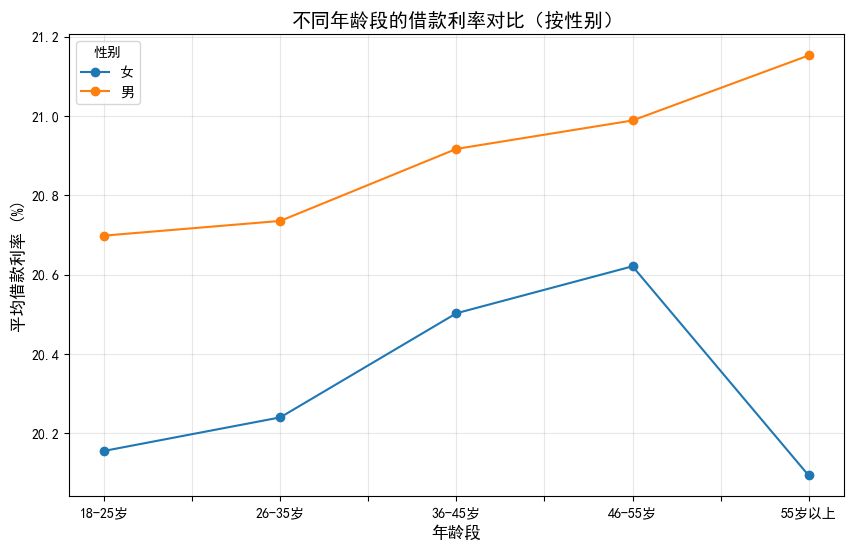

In [123]:
rate_by_age_gender = data.groupby(['年龄段', '性别'])['借款利率'].mean().unstack()

# 2. 绘制折线图
plt.figure(figsize=(10, 6))  # 设置图表大小
rate_by_age_gender.plot(kind='line', marker='o', ax=plt.gca())

# 3. 设置图表标题和标签
plt.title('不同年龄段的借款利率对比（按性别）', fontsize=14)
plt.xlabel('年龄段', fontsize=12)
plt.ylabel('平均借款利率 (%)', fontsize=12)
plt.grid(alpha=0.3)  # 添加网格线，让图表更易读
plt.legend(title='性别')  # 显示图例，并加上标题

# 4. 确保中文正常显示（如果你的图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 5. 显示图表
plt.show()

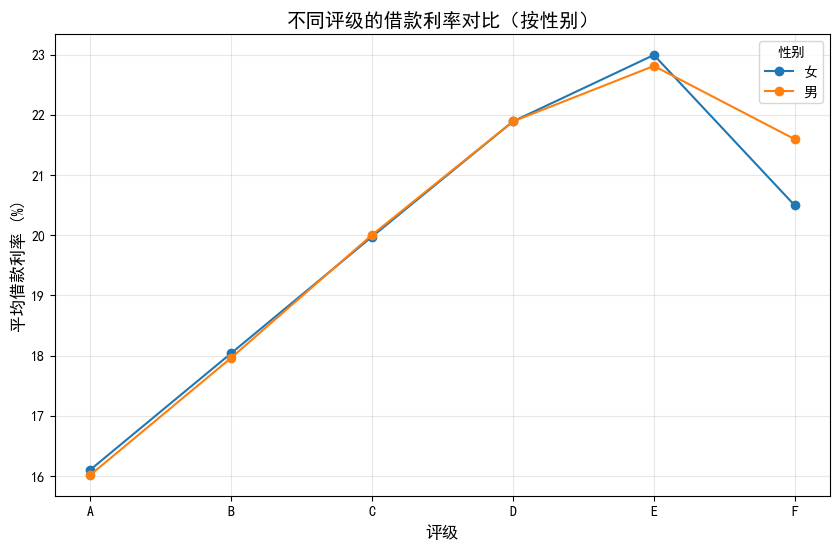

In [129]:


rate_by_age_gender = data.groupby(['初始评级', '性别'])['借款利率'].mean().unstack()

# 2. 绘制折线图
plt.figure(figsize=(10, 6))  # 设置图表大小
rate_by_age_gender.plot(kind='line', marker='o', ax=plt.gca())

# 3. 设置图表标题和标签
plt.title('不同评级的借款利率对比（按性别）', fontsize=14)
plt.xlabel('评级', fontsize=12)
plt.ylabel('平均借款利率 (%)', fontsize=12)
plt.grid(alpha=0.3)  # 添加网格线，让图表更易读
plt.legend(title='性别')  # 显示图例，并加上标题

# 4. 确保中文正常显示（如果你的图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 5. 显示图表
plt.show()

性别,女,男
初始评级,,
A,16.101088,16.014649
B,18.037572,17.960904
C,19.974716,20.004220
D,21.888748,21.888913
E,22.992600,22.810497
F,20.492355,21.593546


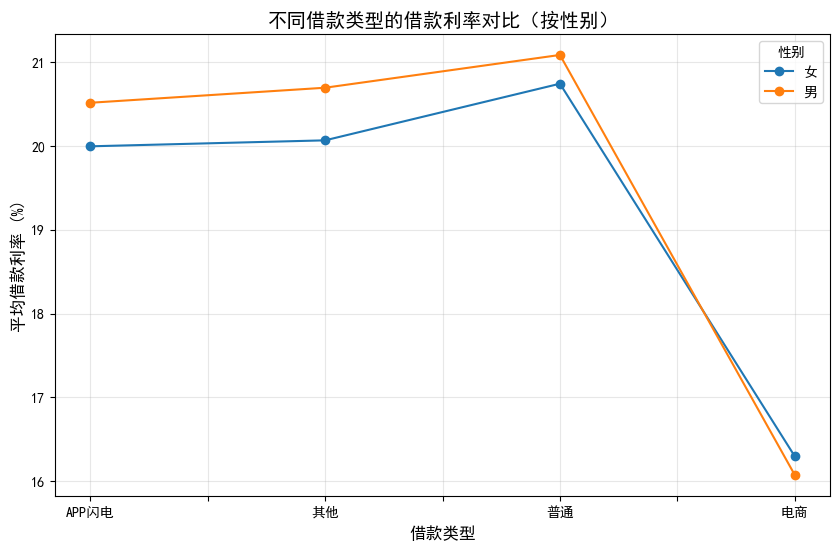

In [130]:


rate_by_age_gender = data.groupby(['借款类型', '性别'])['借款利率'].mean().unstack()

# 2. 绘制折线图
plt.figure(figsize=(10, 6))  # 设置图表大小
rate_by_age_gender.plot(kind='line', marker='o', ax=plt.gca())

# 3. 设置图表标题和标签
plt.title('不同借款类型的借款利率对比（按性别）', fontsize=14)
plt.xlabel('借款类型', fontsize=12)
plt.ylabel('平均借款利率 (%)', fontsize=12)
plt.grid(alpha=0.3)  # 添加网格线，让图表更易读
plt.legend(title='性别')  # 显示图例，并加上标题

# 4. 确保中文正常显示（如果你的图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 5. 显示图表
plt.show()

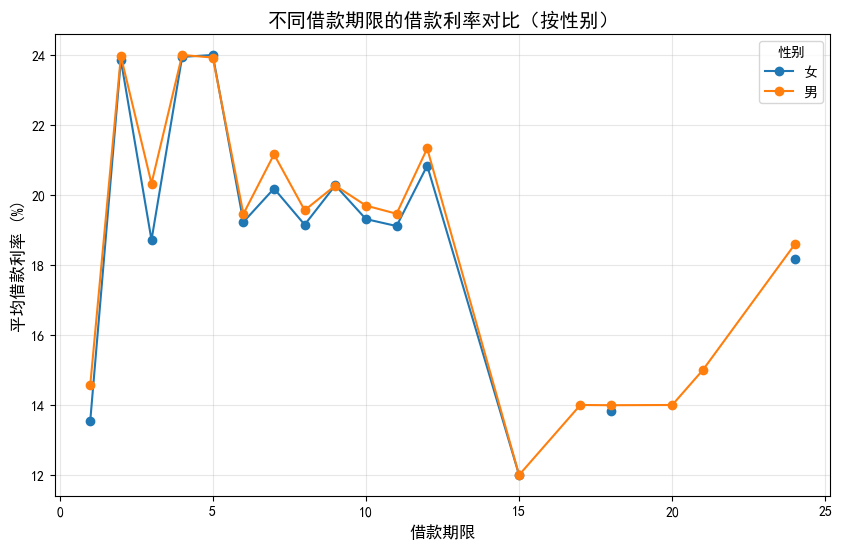

In [131]:


rate_by_age_gender = data.groupby(['借款期限', '性别'])['借款利率'].mean().unstack()

# 2. 绘制折线图
plt.figure(figsize=(10, 6))  # 设置图表大小
rate_by_age_gender.plot(kind='line', marker='o', ax=plt.gca())

# 3. 设置图表标题和标签
plt.title('不同借款期限的借款利率对比（按性别）', fontsize=14)
plt.xlabel('借款期限', fontsize=12)
plt.ylabel('平均借款利率 (%)', fontsize=12)
plt.grid(alpha=0.3)  # 添加网格线，让图表更易读
plt.legend(title='性别')  # 显示图例，并加上标题

# 4. 确保中文正常显示（如果你的图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 5. 显示图表
plt.show()